# [Kaggle] Task 2: Aspect Sentiment Classification (ASC)
## Baselines: TextCNN, RNN, LSTM, GRU, BiLSTM, BiGRU


## 0. Setup


In [1]:
import subprocess, sys, os

# Install dependencies
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'underthesea', 'pytorch-crf', 'gensim'])

# =====================================================
# THAY DOI TEN DATASET DUOI DAY CHO DUNG
# =====================================================
DATA_DATASET = "UIT-ViSD4SA"      # Dataset chua train/dev/test.jsonl
SRC_DATASET  = "absa-src"       # Dataset chua folder src/

IS_KAGGLE = os.path.exists('/kaggle/input')
if IS_KAGGLE:
    DATA_DIR = '/kaggle/input/datasets/danghoang1302/uit-visd4sa'
    SAVE_DIR = '/kaggle/working/results'
    PREP_DIR = '/kaggle/working/preprocessed'

    # Kaggle mount: /kaggle/input/absa-src/src/{asc,ate,e2e,utils}
    # Copy sang working vi Kaggle input la read-only (relative imports can write cache)
    SRC_INPUT = '/kaggle/input/datasets/danghoang1302/absa-src'
    os.system(f'cp -r {SRC_INPUT}/src /kaggle/working/src')
    sys.path.insert(0, '/kaggle/working')

    print(f"KAGGLE | Data: {DATA_DIR}")
    print(f"KAGGLE | Src copied to: /kaggle/working/src/")
else:
    sys.path.insert(0, os.path.abspath(".."))
    DATA_DIR = os.path.join("..", "..", "data")
    SAVE_DIR = os.path.join("..", "..", "results")
    PREP_DIR = os.path.join("..", "..", "preprocessed")
    print(f"LOCAL mode")

# Verify
for fn in ['train.jsonl', 'dev.jsonl', 'test.jsonl']:
    assert os.path.exists(os.path.join(DATA_DIR, fn)), f"MISSING: {fn}"
print("All data files OK!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.0 MB/s eta 0:00:00
KAGGLE | Data: /kaggle/input/datasets/danghoang1302/uit-visd4sa
KAGGLE | Src copied to: /kaggle/working/src/
All data files OK!


## 1. Imports & Load Data


In [2]:
import torch, torch.nn as nn, numpy as np, pandas as pd
from torch.utils.data import DataLoader
from IPython.display import display
from sklearn.metrics import f1_score, confusion_matrix

from src.utils.preprocess import (load_raw_data, segment_items, build_vocab,
                                   train_w2v_embeddings)
from src.asc.asc_dataset import ASCDataset
from src.asc.asc_model import build_asc_model
from src.utils.engine import train_asc_model, predict_asc
from src.utils.metrics import evaluate_asc
from src.utils.visualization import plot_training_curves, plot_model_comparison, plot_confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42); np.random.seed(42)
print(f"Device: {device}")

# Moi notebook tu build vocab + w2v doc lap
train_items = segment_items(load_raw_data(os.path.join(DATA_DIR, "train.jsonl")))
dev_items = segment_items(load_raw_data(os.path.join(DATA_DIR, "dev.jsonl")))
test_items = segment_items(load_raw_data(os.path.join(DATA_DIR, "test.jsonl")))
print(f"Train: {len(train_items)} | Dev: {len(dev_items)} | Test: {len(test_items)}")

all_texts = [item["text"] for item in train_items + dev_items + test_items]
word2idx = build_vocab(all_texts, min_freq=2, special_tokens=["[ASP]"])
VOCAB_SIZE = len(word2idx)
EMB_DIM = 150
emb_matrix = train_w2v_embeddings(all_texts, word2idx, emb_dim=EMB_DIM)
print(f"Vocab: {VOCAB_SIZE} | Emb: {EMB_DIM}d")


Device: cuda
Train: 7785 | Dev: 1112 | Test: 2225
Training Word2Vec 150d...
Embedding Matrix ready. Hit: 6166/6169 (100.0%)
Vocab: 6169 | Emb: 150d


## 2. DataLoaders & Train


In [3]:
MAX_LEN = 128; HIDDEN_DIM = 256; NUM_LAYERS = 2; DROPOUT = 0.3
BATCH_SIZE = 64; EPOCHS = 30; PATIENCE = 7

train_loader = DataLoader(ASCDataset(train_items, word2idx, MAX_LEN), BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(ASCDataset(dev_items, word2idx, MAX_LEN), BATCH_SIZE)
test_loader = DataLoader(ASCDataset(test_items, word2idx, MAX_LEN), BATCH_SIZE)
print(f"ASC Samples - Train: {len(train_loader.dataset)} | Dev: {len(dev_loader.dataset)} | Test: {len(test_loader.dataset)}")

MODEL_TYPES = ["TextCNN", "RNN", "LSTM", "GRU", "BiLSTM", "BiGRU"]
all_models, all_histories = {}, {}
for mt in MODEL_TYPES:
    model = build_asc_model(model_type=mt, vocab_size=VOCAB_SIZE, emb_dim=EMB_DIM,
        hidden_dim=HIDDEN_DIM, num_classes=3, pretrained_emb=emb_matrix,
        n_layers=NUM_LAYERS, dropout=DROPOUT).to(device)
    model, history = train_asc_model(model, train_loader, dev_loader, device,
        lr=1e-3, epochs=EPOCHS, patience=PATIENCE, model_name=mt)
    all_models[mt] = model; all_histories[mt] = history


ASC Samples - Train: 24771 | Dev: 3582 | Test: 7043

  Training TextCNN


Training:   0%|          | 0/388 [00:00<?, ?it/s]

  Ep  1/30 | Train Loss: 0.4816 | Dev Loss: 0.3499 | Dev Mac_F1: 0.6394 | LR: 0.001000 | 7.1s ***


Training:   0%|          | 0/388 [00:00<?, ?it/s]

  Ep  2/30 | Train Loss: 0.3267 | Dev Loss: 0.3198 | Dev Mac_F1: 0.7153 | LR: 0.001000 | 4.6s ***


...

  Ep 18/30 | Train Loss: 0.0187 | Dev Loss: 0.5487 | Dev Mac_F1: 0.8000 | LR: 0.000125 | 17.0s


Training:   0%|          | 0/388 [00:00<?, ?it/s]

  Ep 19/30 | Train Loss: 0.0194 | Dev Loss: 0.5591 | Dev Mac_F1: 0.8078 | LR: 0.000125 | 16.9s


Training:   0%|          | 0/388 [00:00<?, ?it/s]

  Ep 20/30 | Train Loss: 0.0163 | Dev Loss: 0.5787 | Dev Mac_F1: 0.8036 | LR: 0.000063 | 16.9s
  Early stopping at epoch 20 (Best Macro F1: 0.8097)


## 3. Evaluate & Visualize


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Macro_F1,Weighted_F1
5,BiGRU,0.911500,0.805300,0.909500
3,GRU,0.908100,0.802800,0.907800
4,BiLSTM,0.904400,0.793700,0.903500
0,TextCNN,0.883600,0.746500,0.881500
2,LSTM,0.667600,0.404500,0.619200
1,RNN,0.614400,0.254500,0.469000


/kaggle/working/src/utils/visualization.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(fontsize=8)


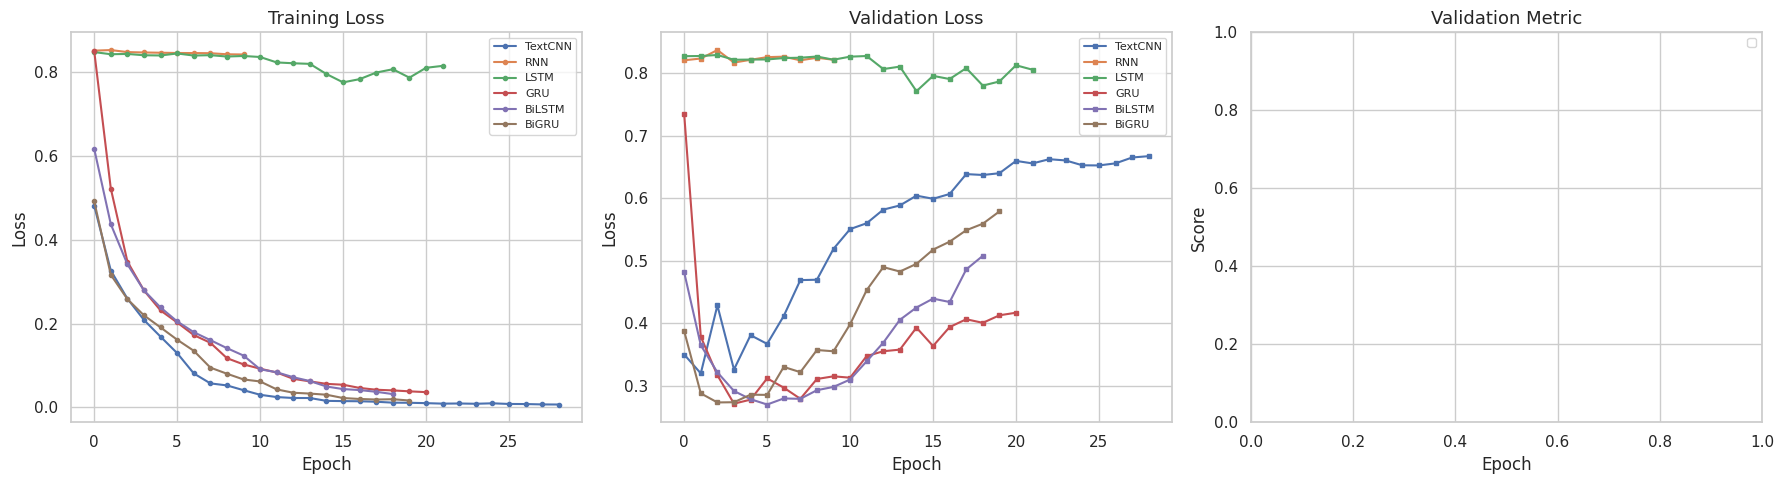

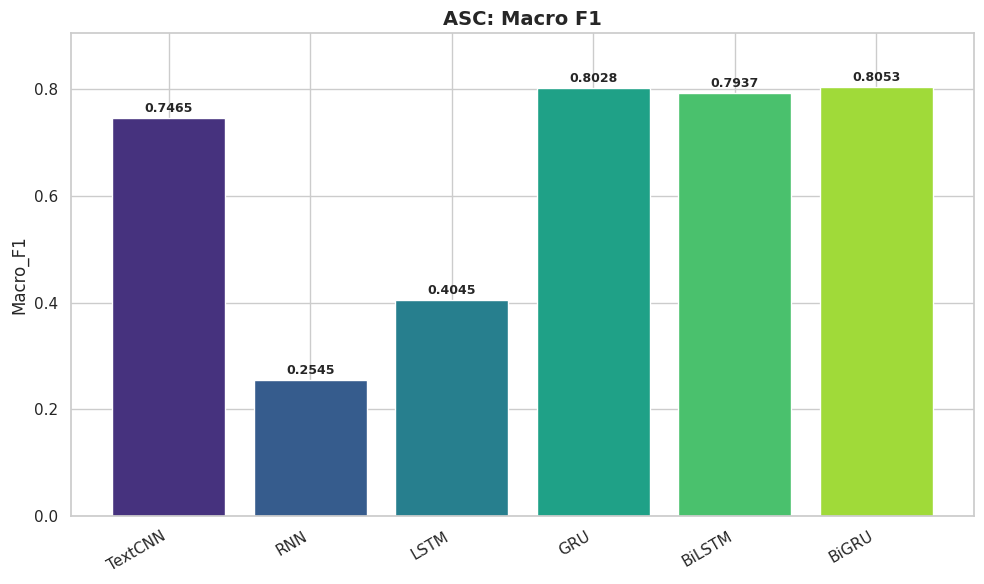

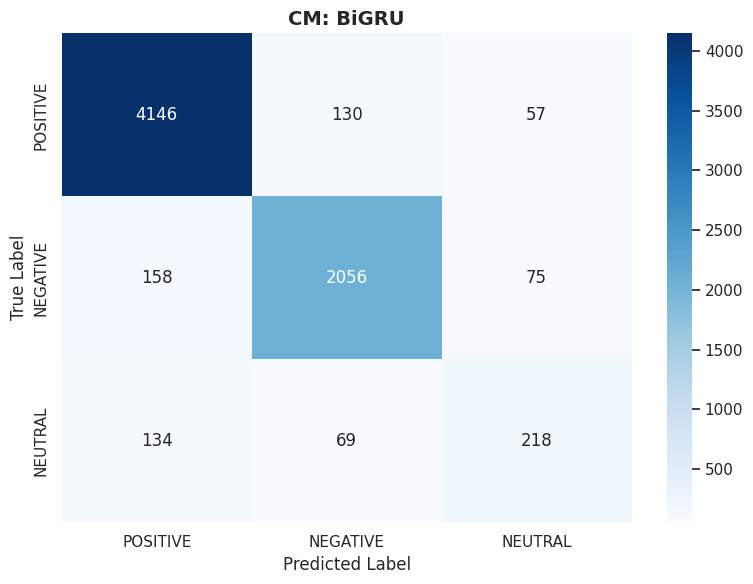

In [4]:
CLASS_NAMES = ["POSITIVE", "NEGATIVE", "NEUTRAL"]
all_results = []; criterion = nn.CrossEntropyLoss()
for mt, model in all_models.items():
    res = predict_asc(model, test_loader, criterion, device)
    m = evaluate_asc(res["labels"], res["preds"], CLASS_NAMES)
    all_results.append({"Model": mt, "Accuracy": round(m["accuracy"],4),
        "Macro_F1": round(m["macro_f1"],4), "Weighted_F1": round(m["weighted_f1"],4)})

results_df = pd.DataFrame(all_results)
display(results_df.sort_values("Macro_F1", ascending=False).style.highlight_max(subset=["Macro_F1"], color="lightgreen"))

plot_training_curves(all_histories)
plot_model_comparison(results_df, metric_col="Macro_F1", title="ASC: Macro F1")

best_name = results_df.loc[results_df["Macro_F1"].idxmax(), "Model"]
best_res = predict_asc(all_models[best_name], test_loader, criterion, device)
best_m = evaluate_asc(best_res["labels"], best_res["preds"], CLASS_NAMES)
plot_confusion_matrix(best_m["confusion_matrix"], CLASS_NAMES, title=f"CM: {best_name}")


## 4. Save


In [5]:
ASC_DIR = os.path.join(SAVE_DIR, "asc"); os.makedirs(ASC_DIR, exist_ok=True)
results_df.to_csv(os.path.join(ASC_DIR, "asc_results.csv"), index=False)
torch.save(all_models[best_name].state_dict(), os.path.join(ASC_DIR, f"best_asc_{best_name}.pt"))
print(f"Best: {best_name} (F1={results_df['Macro_F1'].max():.4f}) -> Saved!")


Best: BiGRU (F1=0.8053) -> Saved!
